In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#add the %matplotlib something was like this


## Let's load the boston house pricing dataset

In [3]:
# from sklearn.datasets import load_boston - removed from current sklearn
# sklearn will give bunch type of data stored in dictionary
# by checking keys of dict we can see the whole data inside bunch
# it will have data(we will make dataframe out of this), target,
# feature names(columns), desr(description),and file name
#info here - https://scikit-learn.org/1.1/modules/generated/sklearn.datasets.load_boston.html

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]]) #this is the data of each row
target = raw_df.values[1::2, 2] #output values of each row
feature_name = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD', 'TAX','PTRATIO','B', 'LSTAT'] #self made column


print(len(feature_name)) #-> comma mistake above mistmatch error
# type(data) #2d array

13


##  Preparing the Dataset

In [4]:
dataset = pd.DataFrame(data, columns = feature_name) #data is the 2d array
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


#### Adding the price(target to dataframe)

In [5]:
#convert target to series
target_series = pd.Series(target) #takes an array
dataset['price'] = target_series
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


#### Analysis or info about the dataset

In [6]:
dataset.info()
#read all the information you get from this
# -info of each column(feature)
# -datatypes, count of values in each column + null or non null
#these are the two main info we get from info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  price    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [7]:
#for mathematical information use describe(stats of data)
dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


#### Check the missing values

In [8]:
dataset.isnull().sum() #null means no value or missed value

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
price      0
dtype: int64

#### Exploratory Data Analysis
#### Correlation between independent features and between indpendent and dependent features

In [9]:
dataset.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


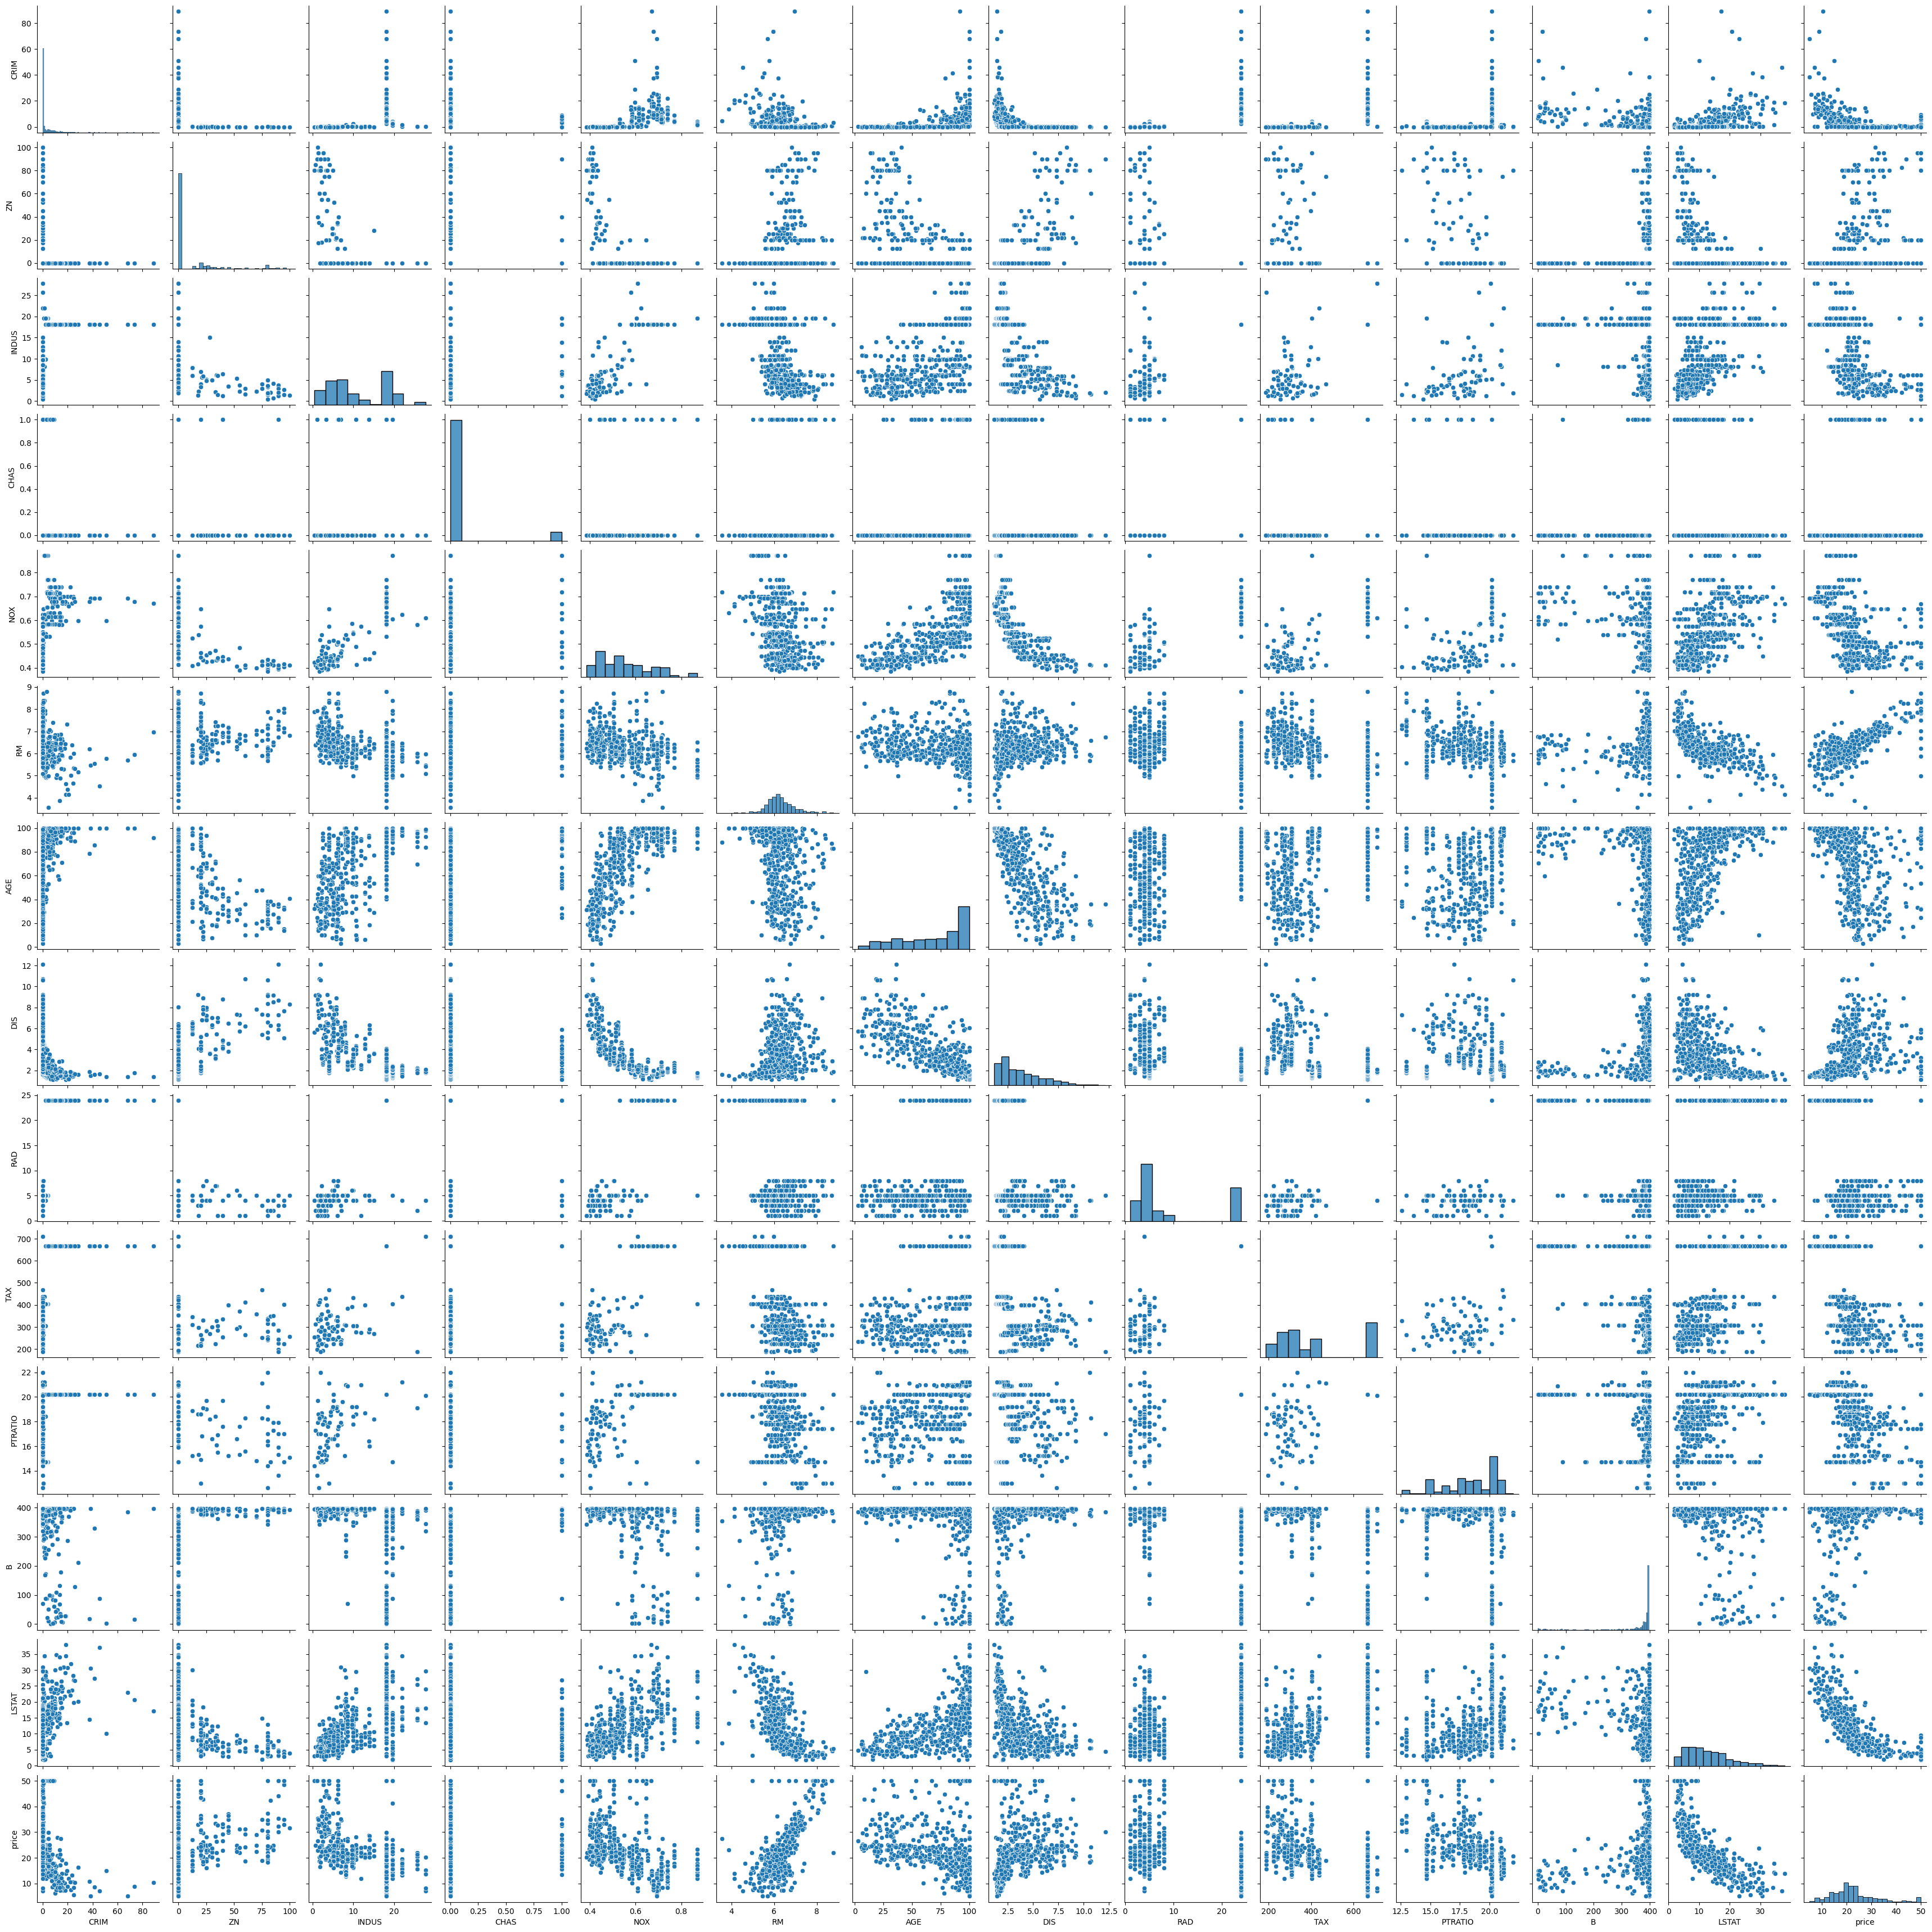

In [14]:
import seaborn as sns
sns.pairplot(dataset)
#plot the scatter plot for every feature vs every feature
#like indus(column) and price column all values as x and y and plot the scatter plot
#if the graph is moving or looking growing means high or close to 1 correlation 
#if it is negatively growing means negative or close to -1 correlation

#### Scatter plot for two featuring to see their relation ship

Text(0, 0.5, 'Price')

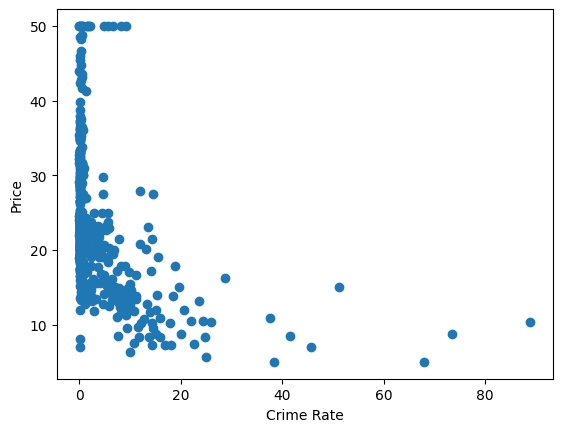

In [15]:
plt.scatter(dataset['CRIM'], dataset['price'])
plt.xlabel('Crime Rate')
plt.ylabel('Price')
# as we can see that as the crime rate increases the price of house decreases

Text(0, 0.5, 'Price')

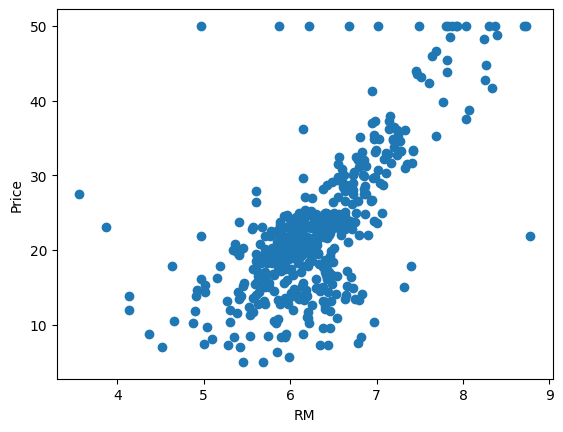

In [16]:
plt.scatter(dataset['RM'], dataset['price'])
plt.xlabel('RM')
plt.ylabel('Price')
# as we can see as the no. of rooms increases the price also increases
# look the graph and analyze how the price increases or decreases on each point
#for example if you look at the last dot on top of a little bit left of 9 its price is around 22 or something
#but the no of room is very high still not that much price this means there are other features also which contributes
#to the price not alone the no. of rooms that is my analysis

#### Regression plot

<Axes: xlabel='RM', ylabel='price'>

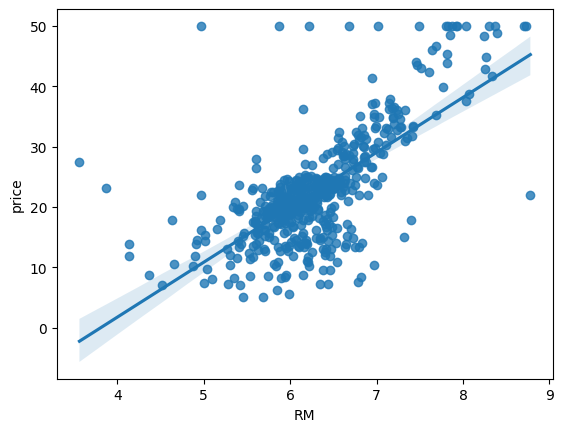

In [17]:
sns.regplot(x = 'RM', y = 'price', data = dataset)

<Axes: xlabel='RAD', ylabel='TAX'>

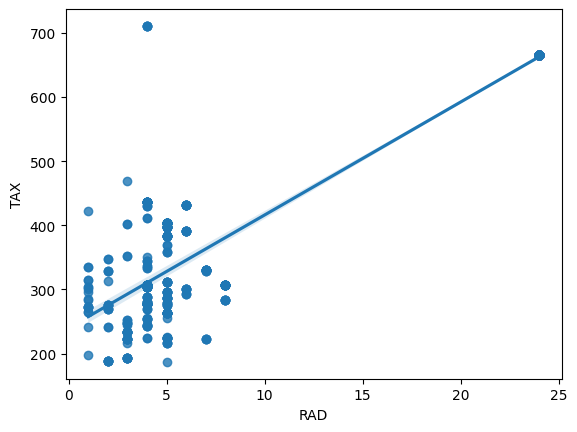

In [18]:
# 0.9 Correlation
sns.regplot(x = 'RAD', y = 'TAX', data = dataset) #very high positive correlation

<Axes: xlabel='CRIM', ylabel='CRIM'>

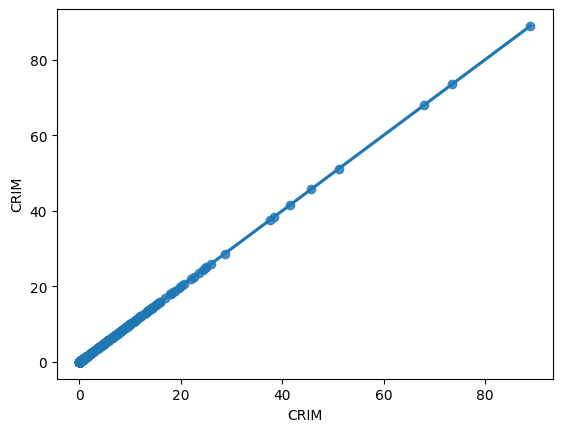

In [19]:
#1 Correlation
sns.regplot(x = 'CRIM', y = 'CRIM', data = dataset) #very high positive correlation = 1(same feature)
#ofcourse it will have same values for x and y for each other as x is y for another feature

<Axes: xlabel='DIS', ylabel='AGE'>

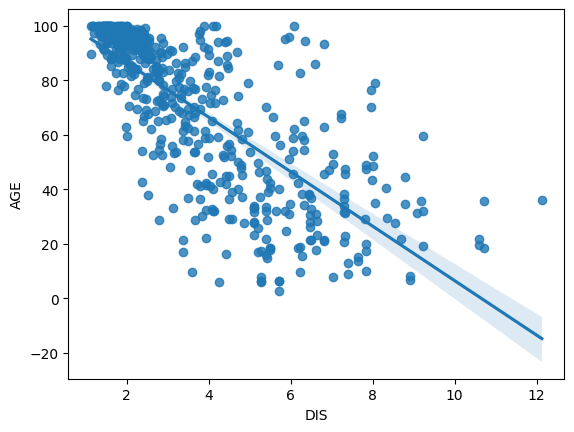

In [20]:
# -0.74 -Correlation
sns.regplot(x = 'DIS', y = 'AGE', data = dataset) 

#####  Very Important point - by the use of correlations we can see whether is there any linear relation between
features or not cuz for maximum output or less error of model for linear regression there should be a linear relation means on change of x(increase, decrease or constant) there should be corresponding change in the y(increase, decrease or constant). Then only Linear agression is applicable or gives best performance

In [21]:
# one more thing i think the linear regression algorithm works like this by the regression line(best fit) it find out
# how the output is changing on change of x (line above the line is of negative slope means an inverse realation) so
# it will predict that if it decreases then there should be a increase in age as the relation is inverse here and after
#combining multiple independent feature the regression line must be the total end line which decides how the relation
# will be of (multiple x) and y after training

### Training The Model

In [22]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]
# dataset

In [23]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [24]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: price, Length: 506, dtype: float64

#### Train Test Split

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.30, random_state = 42)
X_test #here dataframe but after standardizing it become 2d array where each row is element of array

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,4.05,0.0,0.510,6.416,84.1,2.6463,5.0,296.0,16.6,395.50,9.04
274,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4.0,254.0,17.6,396.90,3.53
491,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4.0,711.0,20.1,390.11,18.07
72,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4.0,305.0,19.2,390.91,5.52
452,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24.0,666.0,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,9.72418,0.0,18.10,0.0,0.740,6.406,97.2,2.0651,24.0,666.0,20.2,385.96,19.52
23,0.98843,0.0,8.14,0.0,0.538,5.813,100.0,4.0952,4.0,307.0,21.0,394.54,19.88
225,0.52693,0.0,6.20,0.0,0.504,8.725,83.0,2.8944,8.0,307.0,17.4,382.00,4.63
433,5.58107,0.0,18.10,0.0,0.713,6.436,87.9,2.3158,24.0,666.0,20.2,100.19,16.22


#### Very Important step
Standardize the Dataset to make the whole data in the dataset at the same scale so conversion will be easy

In [26]:
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()

#tfidf is used to convert text into numerical data to fit and tranform the train data
#while scaler is used to standardize the numerical values if you are dealing with numerical data 
#for example the data is age and income so here income has more numbers or value so model will keep that in mind
# and make it more important than age but by standardizing the values by mathematical calculation?

# if one feature is measured in millions (Income) and another in tens (Age), many algorithms will assume
# the higher numbers are more significant. StandardScaler levels the playing field so that both features
# have a Mean ($\mu$) of 0 and a Standard Deviation ($\sigma$) of 1.



In [27]:
X_train = scaler.fit_transform(X_train) #fit and transform

In [28]:
X_test = scaler.transform(X_test)
# we only transfrom test data so the whole train dataset(model) don't know more about the test data
# so that test data will have the same fit features that are in scaler, just need to tranfrom not fit again
# The "Golden Rule" for Scalers:
# Just like your vectorizer, you .fit() on the training data, but you only .transform() the test data. You 
# want to use the training mean and standard deviation to scale your test set!

# When using a scaler, remember the "Golden Rule" of preprocessing to avoid Data Leakage:

# fit_transform on the Training Set: This calculates the mean and standard deviation of the training data and applies it.

# transform (only) on the Test Set: This scales the test data using the same mean and standard deviation from the training set.

In [ ]:
import pickle
pickle.dump(scaler, open('scaling.pkl','wb'))

#also pickling the scaler file
#for standardizing the input data by the user we will use this scaling file so that model get scaled input

### Model Training
Linear Regression
search on web sklearn linear regression and go in the documentation

In [63]:
from sklearn.linear_model import LinearRegression

In [61]:
regression = LinearRegression()

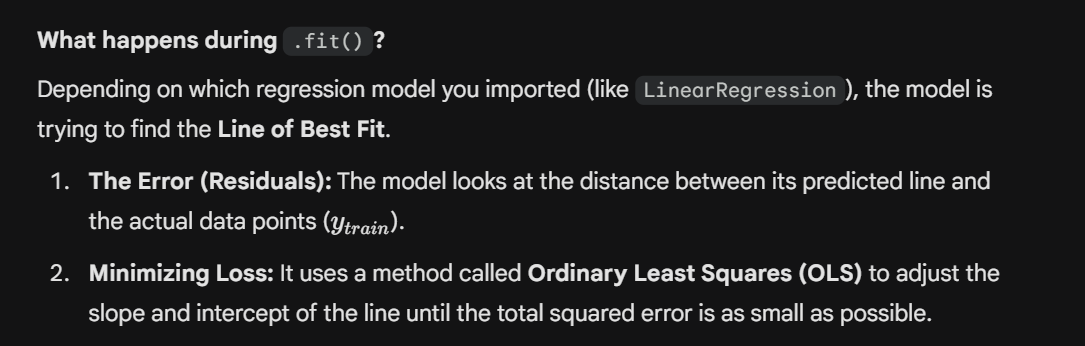

In [31]:
regression.fit(X_train,y_train) #Model Training is done here -> fitting the model
#it will create hyperplanes not 2dline or 3d plane cuz there are so many features

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


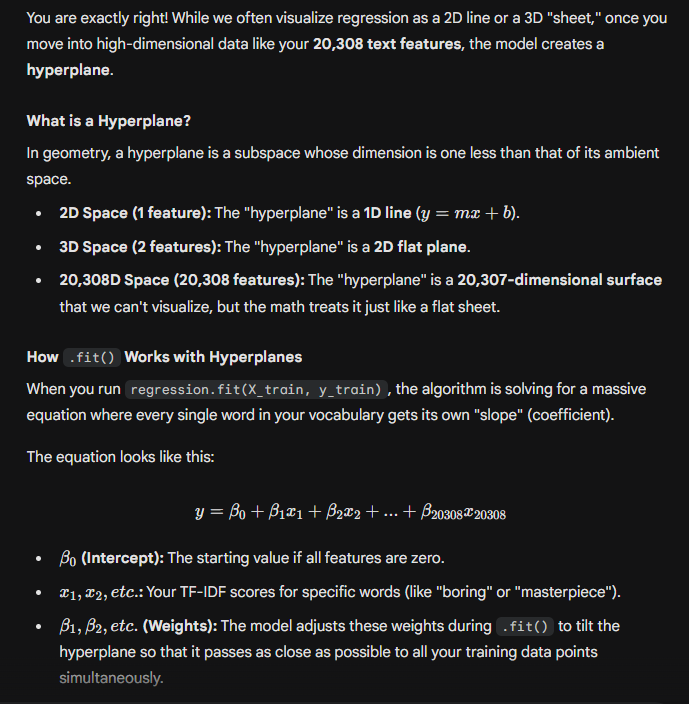

In [32]:
#most important values after fitting
#coefficients and the intercepts
print(regression.coef_) #for each feature
print()
print(regression.intercept_) #intercept is a single value cause it is only one in the regression equation

[-1.10834602  0.80843998  0.34313466  0.81386426 -1.79804295  2.913858
 -0.29893918 -2.94251148  2.09419303 -1.44706731 -2.05232232  1.02375187
 -3.88579002]

23.01581920903955


In [33]:
regression.get_params()
#give the parameters which are present in the .fit( #here )

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

### Prediction on the test data

In [34]:
reg_pred = regression.predict(X_test) #y_test is the true value ->comparision with that will 
# give the model performance on different paramemters

In [35]:
print(y_test) #the index is random cause while splitting the data for train and test it selected random rows

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
441    17.1
23     14.5
225    50.0
433    14.3
447    12.6
Name: price, Length: 152, dtype: float64



### Drawing some plot to see whether the predictions are good or not

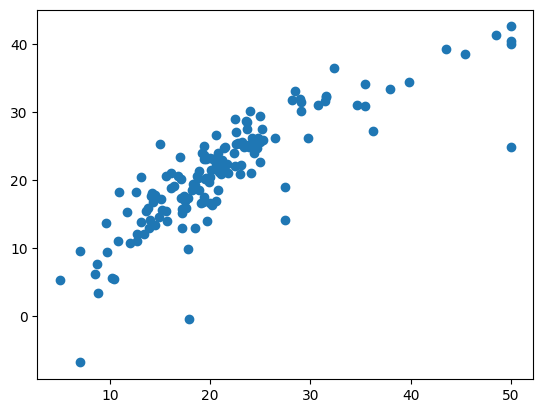

In [36]:
#scatter plot between reg_pred(predicted values) vs y_test(true values)
plt.scatter(y_test, reg_pred)

# a linear relation means the model is performing well
#what i get from this plot is the y_test is the actual value and reg_pred is the predicted values
# the plot between them as one on x and another on y gives the info that if the values are closer, the graph
# will be linear and all the data points will be close to each other(cuz the values are almost same the actual and predicted)
# and if the plot is not linear then there is no good relation between the predicted and the actual values

#### Residual - The error in the acutal value and the predicted 

In [37]:
residuals = y_test - reg_pred
residuals
#so this is the error value of each prediction -> how much difference is there in the predicted and actual value

173    -5.048960
274    -4.095014
491    -1.811193
72     -2.603213
452    -2.755280
         ...    
441    -0.303672
23      1.114059
225    10.016575
433    -2.382863
447    -5.685618
Name: price, Length: 152, dtype: float64

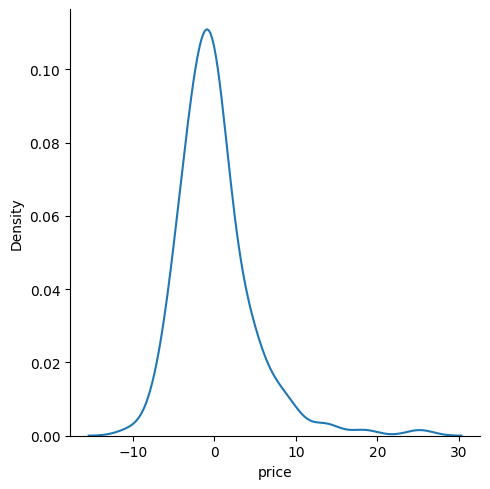

In [38]:
# Plot to see the error range
# like here you can see that on the x axis the range of residuals from -10 to 10 that's the majority error
# and there are some outlier(to much error -> means the predicted value too away from its true value) like 
# after 10 to 30
sns.displot(residuals,kind = 'kde')

#the density shows the relative frquency or probability of occurence of the given error
#the peak of density is at 0 means the most of the error is 0 which is essential for good model performance

#The Area Under the Curve: The total area under the density plot always equals 1 (or 100%). If you look at 
# the "hump" between -10 and 10, the area of that section tells you the percentage of your data that falls
# within that error range.

# The "Closeness" of Predictions: * A tall, skinny peak indicates high density at 0, meaning your model is
# very consistent and its errors are small.

# A short, wide peak indicates low density at 0, meaning your errors are spread out and the model is less precise.

In [39]:
# a Normal Distribution (also known as the "Gaussian Distribution" or "Bell Curve") is a way to describe how 
# data is spread out when most of the values cluster around the middle, and the extreme values taper off 
# symmetrically on both sides.

#getting a normal distribution indicates the model peforms well

#at zero error the frequency is the highest

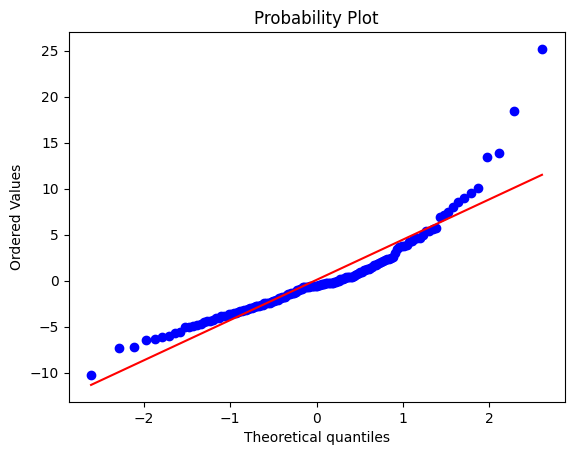

In [40]:
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.show() #will study this plot later

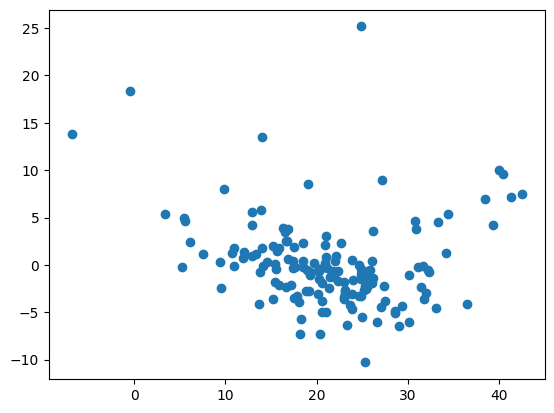

In [41]:
# scatter plot between predicitions ans residuals
plt.scatter(reg_pred, residuals)

#look here there is no patter like normal distribution or any linear format that the plot is follwing it
# is UNIFORMLY DISTRIUBTED means there are error distrubuted across almost all predictions that's why model is 
#performing well

# where the dots look like a random "cloud" with no clear shape or pattern—is called Homoscedasticity.

# KDE Plot: Confirmed your errors are centered at zero (Unbiased). - normal distribution

# Scatter Plot: Confirmed your errors are uniform (Consistent). - uniformly distributed

In [42]:
# Assumption of the linear regression

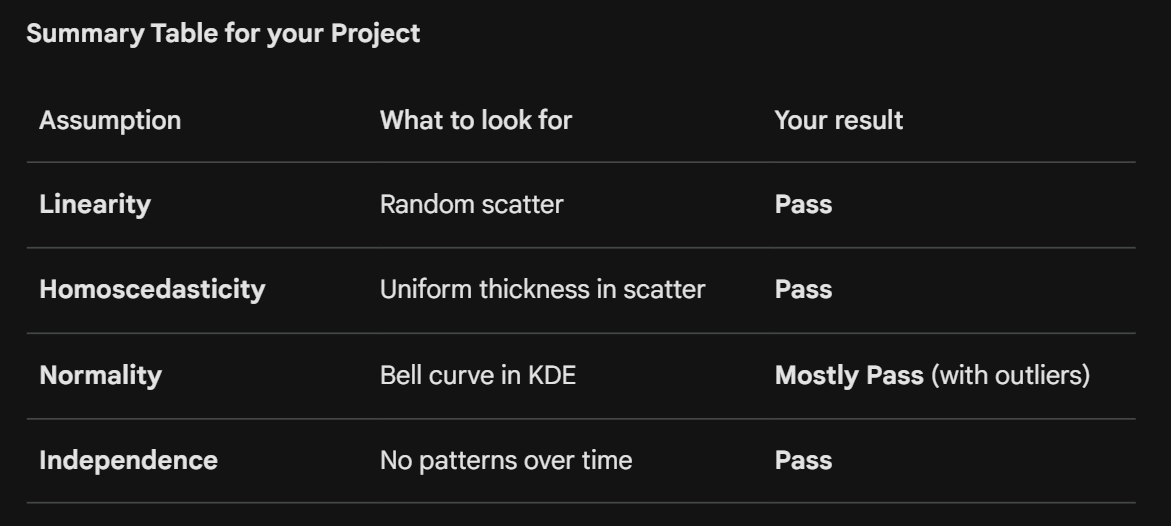

#### Peformance Metrics
#### at the end we have to be sure about the model performance so we use performance metric the above plots and their conceps of like normal distribution in kde, uniform distrubtion in scatter plot are just assumption that it might indicate that the model is performing well but the peformace metrics gives reality to be sure too see how the model actually performed

In [43]:
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae
print(mse(y_test,reg_pred)) #mean squared error
print(mae(y_test,reg_pred)) #mean absolute error
print(np.sqrt(mse(y_test,reg_pred))) #root mean squared error

# How to use these to improve your project:
# If your RMSE is significantly higher than your MAE,
# it means your model is generally good, but it is 
# "tripping up" on a few specific reviews.

21.517444231177205
3.1627098714574053
4.6386899261728205


### R square and adjusted R square

#### Formula
#### R^2 = 1 - SSR/SST
#### R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares

In [44]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.7112260057484934


#### Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]

#### where:

#### R2: The R2 of the model n: The number of observations k: The number of predictor variables

In [45]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6840226584639312

## New Data Prediction

In [46]:
data.shape
X_test #after standardizing by scaler(transforming)
# X_test is the bulk data if we predict on the basis of this data

regression.predict(X_test)

array([28.64896005, 36.49501384, 15.4111932 , 25.40321303, 18.85527988,
       23.14668944, 17.3921241 , 14.07859899, 23.03692679, 20.59943345,
       24.82286159, 18.53057049, -6.86543527, 21.80172334, 19.22571177,
       26.19191985, 20.27733882,  5.61596432, 40.44887974, 17.57695918,
       27.44319095, 30.1715964 , 10.94055823, 24.02083139, 18.07693812,
       15.934748  , 23.12614028, 14.56052142, 22.33482544, 19.3257627 ,
       22.16564973, 25.19476081, 25.31372473, 18.51345025, 16.6223286 ,
       17.50268505, 30.94992991, 20.19201752, 23.90440431, 24.86975466,
       13.93767876, 31.82504715, 42.56978796, 17.62323805, 27.01963242,
       17.19006621, 13.80594006, 26.10356557, 20.31516118, 30.08649576,
       21.3124053 , 34.15739602, 15.60444981, 26.11247588, 39.31613646,
       22.99282065, 18.95764781, 33.05555669, 24.85114223, 12.91729352,
       22.68101452, 30.80336295, 31.63522027, 16.29833689, 21.07379993,
       16.57699669, 20.36362023, 26.15615896, 31.06833034, 11.98

In [47]:
data[0] #single row or just one input data value #data was list of list and each inside list is the data(features) 
# here we select the first row

array([6.320e-03, 1.800e+01, 2.310e+00, 0.000e+00, 5.380e-01, 6.575e+00,
       6.520e+01, 4.090e+00, 1.000e+00, 2.960e+02, 1.530e+01, 3.969e+02,
       4.980e+00])

In [48]:
data[0].shape #1d array

(13,)

In [49]:
#reshape in 2d array
data[0].reshape(1,-1).shape

(1, 13)

In [50]:
regression.predict(data[0].reshape(1,-1))
#gives a negative value cuz we didn't standardize the new data like in the first step above before fitting data

array([-45.64344024])

In [51]:
#standardize
new_data = scaler.transform(data[0].reshape(1,-1))

c:\Users\Suraj\.conda\envs\venv2\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [52]:
regression.predict(new_data)

array([30.08649576])

In [53]:
# #import step 
# in the binary text classification we did the same thing
# tfidf.fit_transform for the X_train and tfidf.transform for X_test
# while predicting for X_test we don't need to transfrom cuz it is already done in the first step

# for new data as well we need to transfrom tfidf.transform("text") #the one i call change to numerical first

# here the same case for scaler
# for new data scaler.transform

## Pickling the model file for deployment 

In [54]:
import pickle #for deploying the model we use it ,saving the file in the pickle format
pickle.dump(regression,open('regmodel.pkl','wb')) #the .pkl is the file extension and wb write byte mode

#pickle file is serializable format means, we can use this file to predict on any server or web application

In [55]:
#loading the saved file from storage
pickled_file = pickle.load(open('regmodel.pkl','rb')) #read byte mode

In [56]:
pickled_file.predict(new_data) #works same as regression 

array([30.08649576])